# Fraud Detection — ML Pipeline
**Dataset:** Enriched synthetic financial fraud data (50k rows, 31 cols)

**Pipeline:** Load → EDA → Preprocess → Handle Imbalance → Train multiple models → Compare → Save best

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('All imports successful')

All imports successful


## 2. Load Dataset

In [2]:
df = pd.read_csv('enriched_fraud_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 31)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,multiple_accounts_on_device,ip_asn_type,failed_logins_7d,copy_paste_used,otp_retry_count,time_to_submit_form_sec,email_domain_type,email_age_days,phone_type,email_breach_count
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,...,False,mobile,0,True,1,131,disposable,1178,mobile,1
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,...,False,mobile,0,False,0,108,personal,1042,voip,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,...,False,residential,0,False,2,106,personal,295,landline,4
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,...,False,vpn,4,True,2,125,disposable,0,mobile,3
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,...,False,mobile,0,False,2,47,personal,1399,mobile,0


In [3]:
print('Dtypes:')
print(df.dtypes)
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nFraud rate: {df["isFraud"].mean()*100:.3f}%')
print(f'Fraud count: {df["isFraud"].sum()} / {len(df)}')

Dtypes:
step                             int64
type                               str
amount                         float64
nameOrig                           str
oldbalanceOrg                  float64
newbalanceOrig                 float64
nameDest                           str
oldbalanceDest                 float64
newbalanceDest                 float64
isFraud                          int64
isFlaggedFraud                   int64
kyc_verified                      bool
kyc_attempts                     int64
face_match_score               float64
sanctions_hit                     bool
credit_score                     int64
bureau_enquiries_30d             int64
dpd_90                           int64
debt_to_income_ratio           float64
is_rooted_jailbroken              bool
vpn_detected                      bool
multiple_accounts_on_device       bool
ip_asn_type                        str
failed_logins_7d                 int64
copy_paste_used                   bool
otp_retry_count  


Fraud rate: 1.200%
Fraud count: 600 / 50000


## 3. EDA

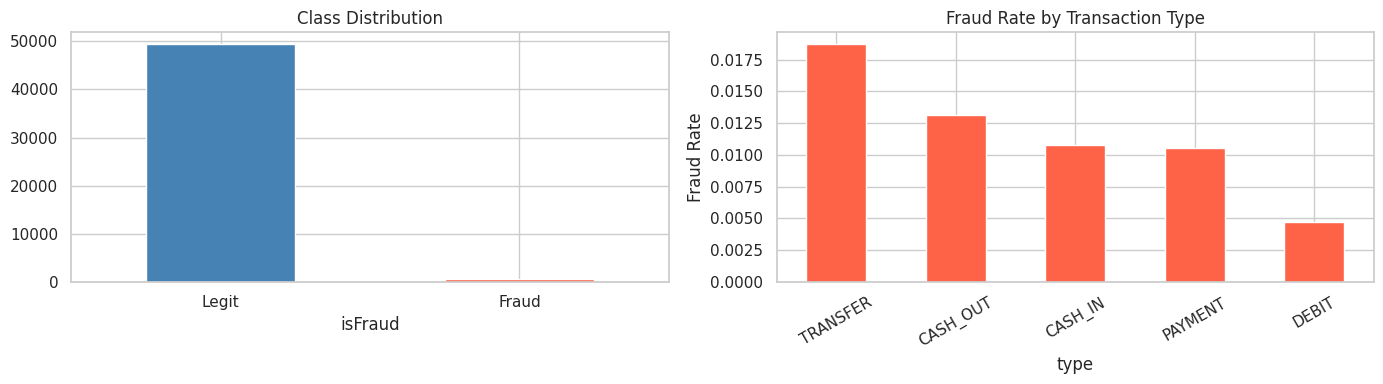

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
df['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# Fraud by transaction type
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Fraud Rate by Transaction Type')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

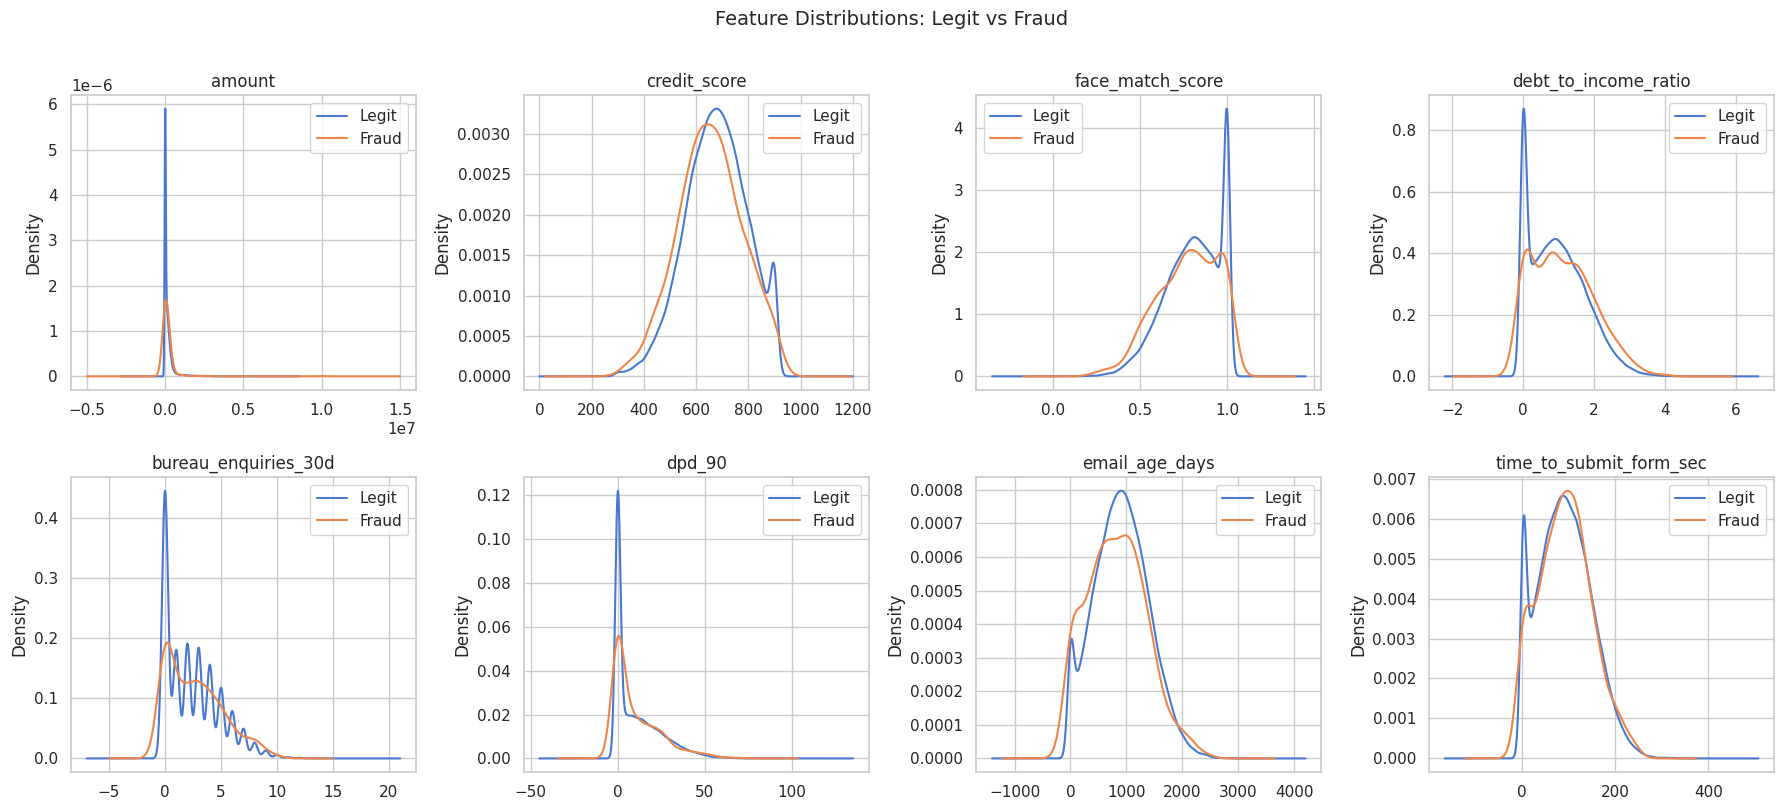

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

num_cols = ['amount', 'credit_score', 'face_match_score', 'debt_to_income_ratio',
            'bureau_enquiries_30d', 'dpd_90', 'email_age_days', 'time_to_submit_form_sec']

for i, col in enumerate(num_cols):
    df.groupby('isFraud')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(col)
    axes[i].legend(['Legit', 'Fraud'])

plt.suptitle('Feature Distributions: Legit vs Fraud', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

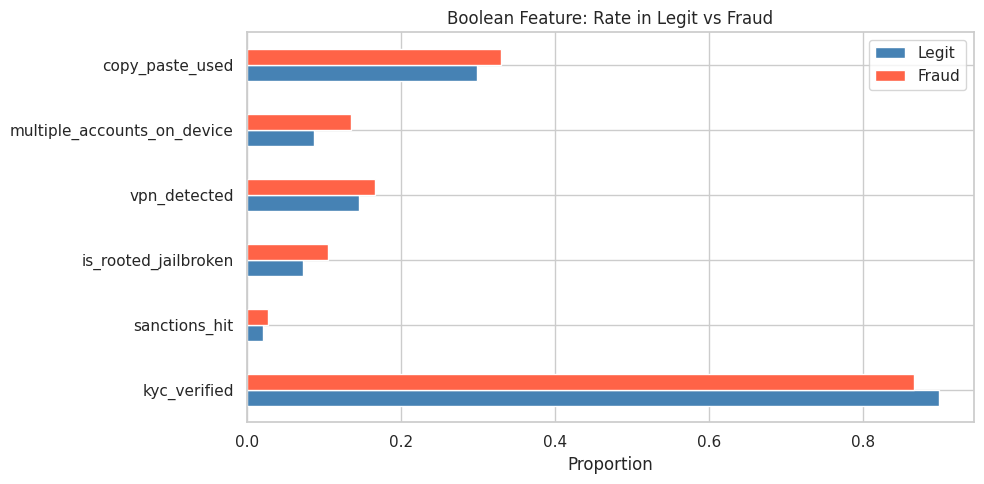

In [6]:
bool_cols = ['kyc_verified', 'sanctions_hit', 'is_rooted_jailbroken',
             'vpn_detected', 'multiple_accounts_on_device', 'copy_paste_used']

fraud_bool = df.groupby('isFraud')[bool_cols].mean().T
fraud_bool.columns = ['Legit', 'Fraud']
fraud_bool.plot(kind='barh', figsize=(10, 5), color=['steelblue', 'tomato'])
plt.title('Boolean Feature: Rate in Legit vs Fraud')
plt.xlabel('Proportion')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [7]:
# Drop identifier columns not useful for model
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=drop_cols)

# Encode categoricals
cat_cols = ['type', 'ip_asn_type', 'email_domain_type', 'phone_type']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Convert booleans to int
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print('Final columns:', df.columns.tolist())
print('Shape:', df.shape)

Final columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'kyc_verified', 'kyc_attempts', 'face_match_score', 'sanctions_hit', 'credit_score', 'bureau_enquiries_30d', 'dpd_90', 'debt_to_income_ratio', 'is_rooted_jailbroken', 'vpn_detected', 'multiple_accounts_on_device', 'ip_asn_type', 'failed_logins_7d', 'copy_paste_used', 'otp_retry_count', 'time_to_submit_form_sec', 'email_domain_type', 'email_age_days', 'phone_type', 'email_breach_count']
Shape: (50000, 28)


In [8]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train fraud: {y_train.sum()} | Test fraud: {y_test.sum()}')

Train: (40000, 27) | Test: (10000, 27)
Train fraud: 480 | Test fraud: 120


## 5. Handle Class Imbalance — SMOTE

In [9]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')

Before SMOTE: {0: 39520, 1: 480}
After  SMOTE: {0: 39520, 1: 39520}


## 6. Define Models

In [10]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                class_weight='balanced', random_state=42, verbose=-1)
}

print(f'{len(models)} models to train:', list(models.keys()))

6 models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 7. Train & Evaluate All Models

In [11]:
results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc  = roc_auc_score(y_test, y_proba)
    pr_auc   = average_precision_score(y_test, y_proba)
    report   = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model':     name,
        'ROC-AUC':   round(roc_auc, 4),
        'PR-AUC':    round(pr_auc, 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1-Score':  round(report['1']['f1-score'], 4),
        'Accuracy':  round(report['accuracy'], 4),
    })
    print(f'  ROC-AUC={roc_auc:.4f} | PR-AUC={pr_auc:.4f} | F1={report["1"]["f1-score"]:.4f}')

results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison ===')
results_df

Training Logistic Regression...


  ROC-AUC=0.4967 | PR-AUC=0.0295 | F1=0.0246
Training Decision Tree...


  ROC-AUC=0.5532 | PR-AUC=0.0140 | F1=0.0292
Training Random Forest...


  ROC-AUC=0.5518 | PR-AUC=0.0189 | F1=0.0088
Training Gradient Boosting...


  ROC-AUC=0.5368 | PR-AUC=0.0287 | F1=0.0333
Training XGBoost...


  ROC-AUC=0.5275 | PR-AUC=0.0225 | F1=0.0236
Training LightGBM...


  ROC-AUC=0.5408 | PR-AUC=0.0231 | F1=0.0291

=== Model Comparison ===


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,0.4967,0.0295,0.0128,0.2833,0.0246,0.7302
1,Gradient Boosting,0.5368,0.0287,0.0185,0.1667,0.0333,0.8837
2,LightGBM,0.5408,0.0231,0.0159,0.1667,0.0291,0.8666
3,XGBoost,0.5275,0.0225,0.0121,0.4750,0.0236,0.5276
4,Random Forest,0.5518,0.0189,0.0094,0.0083,0.0088,0.9776
5,Decision Tree,0.5532,0.0140,0.0152,0.3667,0.0292,0.7076


## 8. Model Comparison Visualization

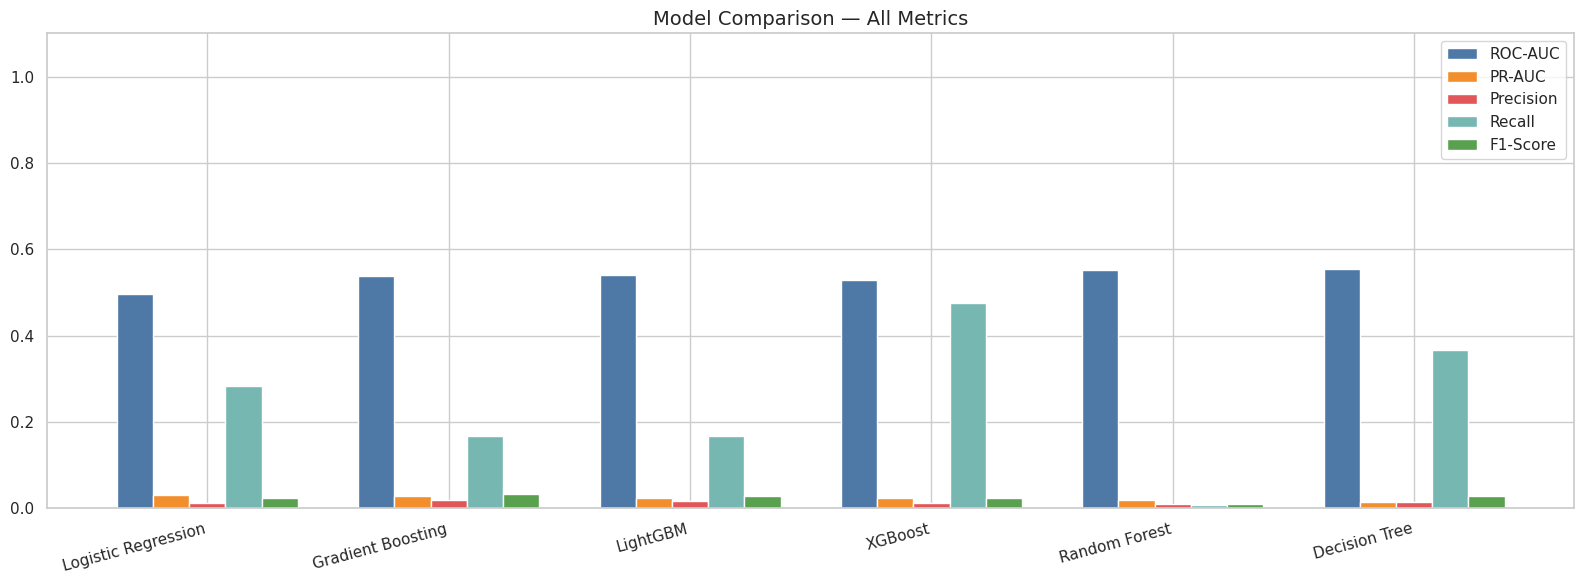

In [12]:
metrics = ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — All Metrics', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

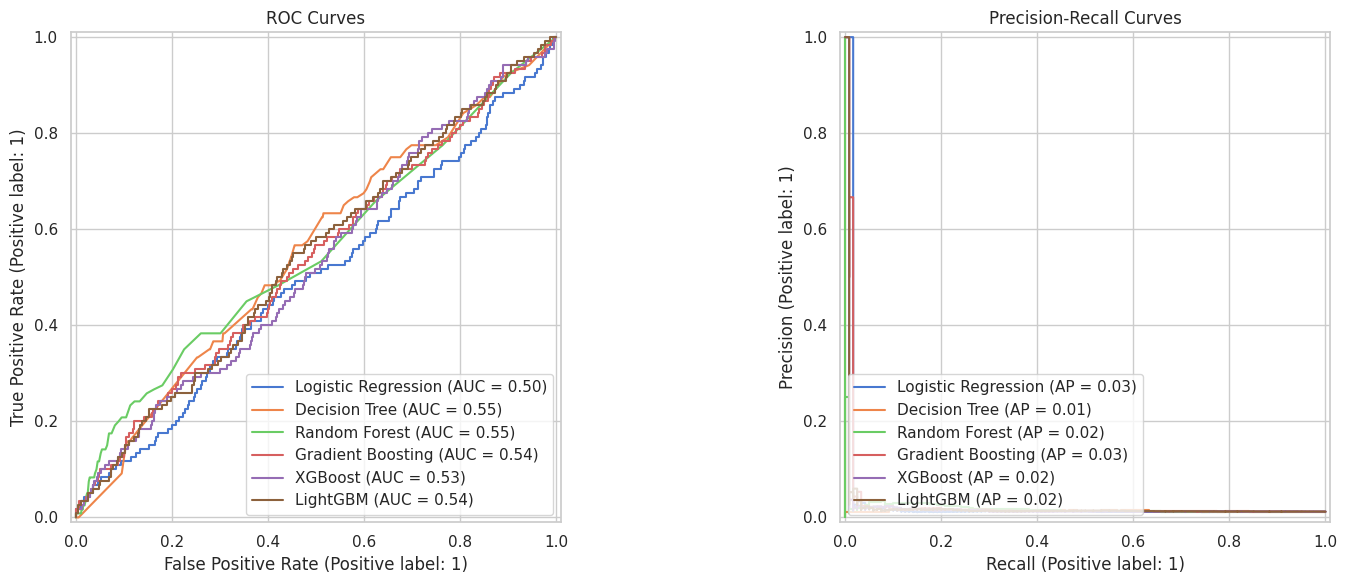

In [13]:
# ROC & PR Curves for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])

axes[0].set_title('ROC Curves')
axes[1].set_title('Precision-Recall Curves')
plt.tight_layout()
plt.show()

## 9. Best Model — Deep Dive

In [14]:
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
print(f'Best model by PR-AUC: {best_name}')
print(f'\nClassification Report:')
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Legit', 'Fraud']))

Best model by PR-AUC: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.74      0.84      9880
       Fraud       0.01      0.28      0.02       120

    accuracy                           0.73     10000
   macro avg       0.50      0.51      0.43     10000
weighted avg       0.98      0.73      0.83     10000



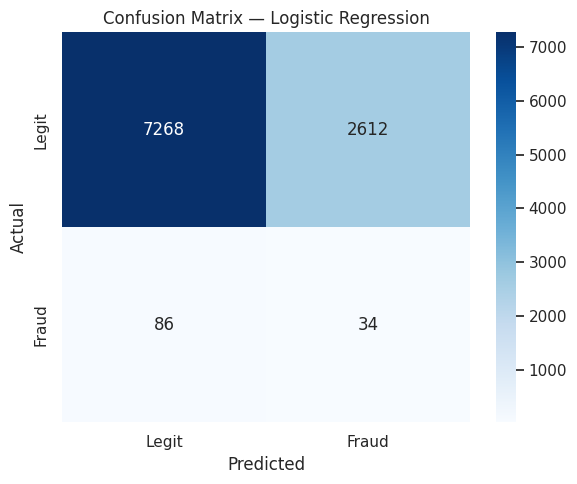

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

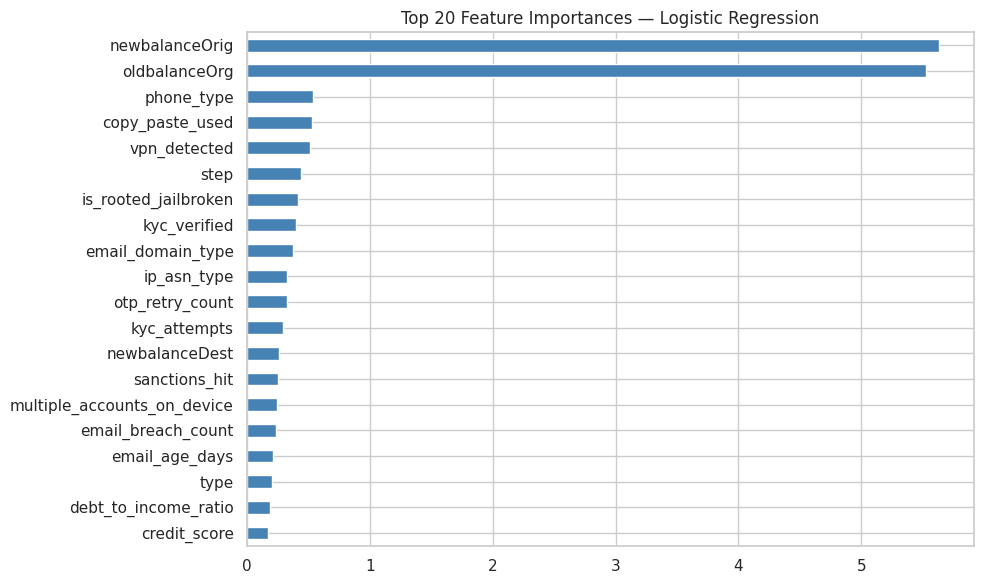

In [16]:
# Feature Importance (tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'named_steps'):
    importances = best_model.named_steps['clf'].coef_[0]
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=X.columns).abs().sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()

## 10. Save Best Model

In [17]:
os.makedirs('saved_models', exist_ok=True)

model_path = f'saved_models/best_fraud_model_{best_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_path)
print(f'Model saved → {model_path}')

# Save full leaderboard
results_df.to_csv('saved_models/model_leaderboard.csv', index=False)
print('Leaderboard saved → saved_models/model_leaderboard.csv')

# Verify load
loaded = joblib.load(model_path)
y_verify = loaded.predict_proba(X_test[:5])[:, 1]
print(f'\nVerification — sample fraud probabilities: {y_verify.round(4)}')

Model saved → saved_models/best_fraud_model_logistic_regression.pkl
Leaderboard saved → saved_models/model_leaderboard.csv

Verification — sample fraud probabilities: [0.3132 0.0238 0.4649 0.1128 0.2434]


## Summary

| Step | What was done |
|---|---|
| Data | 50k rows, 30 features (financial + KYC + bureau + device + telemetry + social) |
| Imbalance | SMOTE oversampling on training set |
| Models | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM |
| Selection | Best model chosen by **PR-AUC** (most relevant for imbalanced fraud data) |
| Saved | `saved_models/best_fraud_model_<name>.pkl` |
